In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#file1 = "/work/scitas-ge/panchal/J0737-3039A_1261241272_2248_4048/G0057_1261241272_07:37:51.25_-30:39:40.71_ch109-132_0002.fits"
#file2 = "/work/scitas-ge/panchal/J0737-3039A_1261241272_2248_4048_StokesI/G0057_1261241272_07:37:51.25_-30:39:40.71_ch109-132_0002.fits"

file1 = "/work/scitas-ge/panchal/chrisleedatasetfull/J0030+0451_1255444104_0436_2236/G0057_1255444104_00:30:27.42_+04:51:39.73_ch109-132_0001.fits"
file2 = "/work/scitas-ge/panchal/J0030+0451_1255444104_0436_2236_StokesI/G0057_1255444104_00:30:27.43_+04:51:39.71_ch109-132_0001.fits"

In [3]:
fits.open(file1).info()

Filename: /work/scitas-ge/panchal/chrisleedatasetfull/J0030+0451_1255444104_0436_2236/G0057_1255444104_00:30:27.42_+04:51:39.73_ch109-132_0001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      57   ()      
  1  SUBINT        1 BinTableHDU     74   200R x 17C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 3072E, 3072E, 12288E, 12288E, 122880000B]   


In [4]:
fits.open(file2).info()

Filename: /work/scitas-ge/panchal/J0030+0451_1255444104_0436_2236_StokesI/G0057_1255444104_00:30:27.43_+04:51:39.71_ch109-132_0001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      57   ()      
  1  SUBINT        1 BinTableHDU     74   200R x 17C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 3072E, 3072E, 3072E, 3072E, 30720000B]   


In [5]:
def getData(hdul, num_rows, poln):
    # Extract relevant data columns from file 1
    data = hdul[1].data
    hdul[0].header
    print(data.names)
    
    nchans = hdul[1].header["NCHAN"]
    npoln = hdul[1].header["NPOL"]
    nsblk = hdul[1].header["NSBLK"]
    
    data_wts = data['DAT_WTS'][0:num_rows, :]
    data_offs = data['DAT_OFFS'][0:num_rows, nchans * poln : nchans * poln + nchans]
    data_scls = data['DAT_SCL'][0:num_rows, nchans * poln : nchans * poln + nchans]
    data_bytes = data['DATA'][0:num_rows, :, poln, :,0]
    
    print(f"complete data shape: {data['DATA'].shape}")
    
    print(f"data_wts shape: {data_wts.shape}")
    print(f"data_offs shape: {data_offs.shape}")
    print(f"data_scls shape: {data_scls.shape}")
    print(f"data_bytes shape: {data_bytes.shape}")

    return data_wts, data_offs, data_scls, data_bytes

In [6]:
# Extract relevant data columns from file 1
data_wts1, data_offs1, data_scls1, data_bytes1 = getData(fits.open(file1), 200, 0)

['TSUBINT', 'OFFS_SUB', 'LST_SUB', 'RA_SUB', 'DEC_SUB', 'GLON_SUB', 'GLAT_SUB', 'FD_ANG', 'POS_ANG', 'PAR_ANG', 'TEL_AZ', 'TEL_ZEN', 'DAT_FREQ', 'DAT_WTS', 'DAT_OFFS', 'DAT_SCL', 'DATA']
complete data shape: (200, 10000, 4, 3072, 1)
data_wts shape: (200, 3072)
data_offs shape: (200, 3072)
data_scls shape: (200, 3072)
data_bytes shape: (200, 10000, 3072)


In [7]:
# Extract relevant data columns from file 1
data_wts2, data_offs2, data_scls2, data_bytes2 = getData(fits.open(file2), 200, 0)

['TSUBINT', 'OFFS_SUB', 'LST_SUB', 'RA_SUB', 'DEC_SUB', 'GLON_SUB', 'GLAT_SUB', 'FD_ANG', 'POS_ANG', 'PAR_ANG', 'TEL_AZ', 'TEL_ZEN', 'DAT_FREQ', 'DAT_WTS', 'DAT_OFFS', 'DAT_SCL', 'DATA']
complete data shape: (200, 10000, 1, 3072, 1)
data_wts shape: (200, 3072)
data_offs shape: (200, 3072)
data_scls shape: (200, 3072)
data_bytes shape: (200, 10000, 3072)


In [8]:
# Comparing 
diff1 = np.abs(data_wts1-data_wts2)
diff2 = np.abs(data_offs1-data_offs2)
diff3 = np.abs(data_scls1-data_scls2)
diff4 = np.abs(data_bytes1-data_bytes2)

print(f"data_wts equal = {np.max(diff1)}")
print(f"data_offs equal = {np.max(diff2)}")
print(f"data_scls equal = {np.max(diff3)}")
print(f"data_bytes equal = {np.max(diff4)}")

data_wts equal = 0.0
data_offs equal = 0.021877288818359375
data_scls equal = 0.0003380775451660156
data_bytes equal = 255


In [9]:
print(np.sum(diff4 > 0))

26527960


(200, 3072)


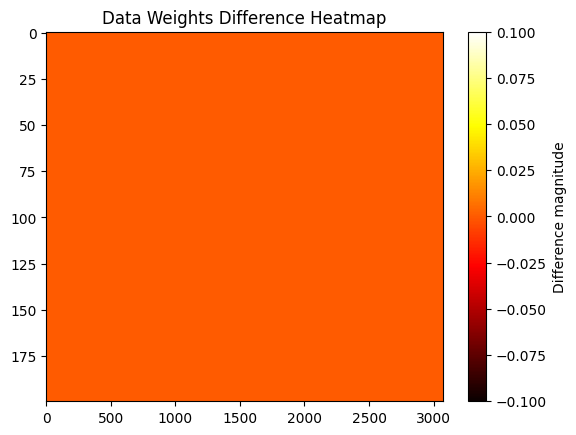

In [10]:
print(diff1.shape)
plt.figure()
plt.imshow(diff1, cmap="hot", aspect="auto")
plt.colorbar(label="Difference magnitude")
plt.title("Data Weights Difference Heatmap")
plt.show()

(200, 3072)


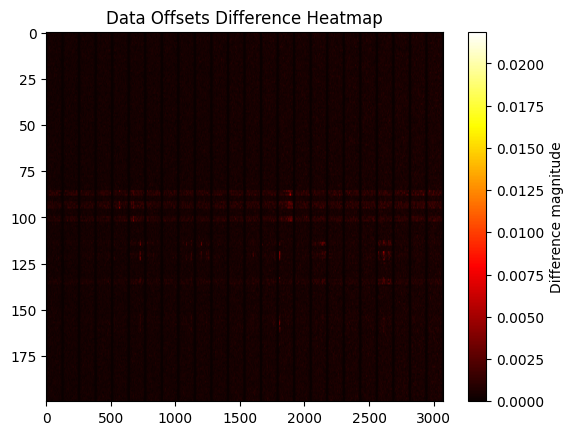

In [11]:
print(diff2.shape)
plt.figure()
plt.imshow(diff2, cmap="hot", aspect="auto")
plt.colorbar(label="Difference magnitude")
plt.title("Data Offsets Difference Heatmap")
plt.show()

(200, 3072)


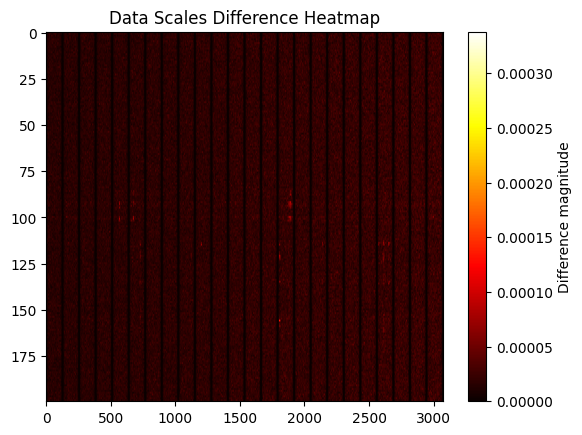

In [12]:
print(diff3.shape)
plt.figure()
plt.imshow(diff3, cmap="hot", aspect="auto")
plt.colorbar(label="Difference magnitude")
plt.title("Data Scales Difference Heatmap")
plt.show()

In [13]:
shape4 = diff4.shape
print(shape4)
diff4modif = diff4.reshape(shape4[0]*shape4[1], shape4[2])

(200, 10000, 3072)


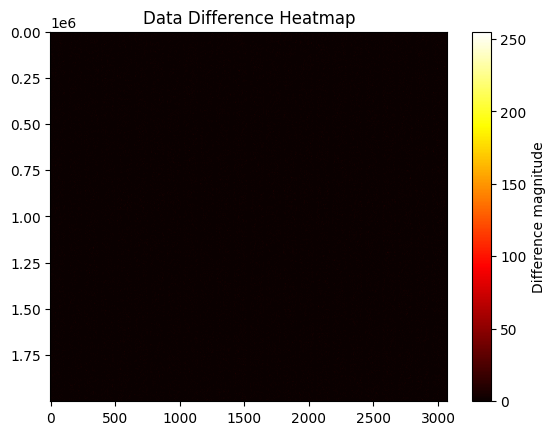

In [14]:
plt.figure()
plt.imshow(diff4modif, cmap="hot", aspect="auto")
plt.colorbar(label="Difference magnitude")
plt.title("Data Difference Heatmap")
plt.show()

In [ ]:
# Comparing 
# Comparing 
print(f"data_wts equal = {np.array_equal(data_wts1, data_wts2)}")

diff_offs = np.abs(data_offs1 - data_offs2)
idx_offs = np.unravel_index(np.argmax(diff_offs), diff_offs.shape)
print(f"data_offs max diff = {diff_offs[idx_offs]} at {idx_offs}")

diff_scls = np.abs(data_scls1 - data_scls2)
idx_scls = np.unravel_index(np.argmax(diff_scls), diff_scls.shape)
print(f"data_scls max diff = {diff_scls[idx_scls]} at {idx_scls}")

diff_bytes = np.abs(data_bytes1 - data_bytes2)
idx_bytes = np.unravel_index(np.argmax(diff_bytes), diff_bytes.shape)
print(f"data_bytes max diff = {diff_bytes[idx_bytes]} at {idx_bytes}")

In [ ]:
row = 4
poln1 = 0
data_wts1 = data1['DAT_WTS'][row, :]
data_offs1 = data1['DAT_OFFS'][row, nchans1 * poln1 : nchans1 * poln1 + 10]
data_scls1 = data1['DAT_SCL'][row, nchans1 * poln1 : nchans1 * poln1 + 10]
data_bytes1 = data1['DATA'][row, :, poln1, :,0]

poln2 = 0
data_wts2 = data2['DAT_WTS'][row, :]
data_offs2 = data2['DAT_OFFS'][row, nchans2 * poln2 : nchans2 * poln2 + 10]
data_scls2 = data2['DAT_SCL'][row, nchans2 * poln2 : nchans2 * poln2 + 10]
data_bytes2 = data2['DATA'][row, :, poln2, :,0]

In [ ]:
print(f"data_wts1:\n {data_wts1}")
print(f"data_wts2:\n {data_wts2}")

In [ ]:
print(f"data_offs1:\n {data_offs1}")
print(f"data_offs2:\n {data_offs2}")

In [ ]:
print(f"data_scls1:\n {data_scls1}")
print(f"data_scls2:\n {data_scls2}")

In [ ]:
print(f"data_bytes1:\n {data_bytes1}")
print(f"data_bytes2:\n {data_bytes2}")

In [ ]:
############################################################################################

In [ ]:
# Convert byte data to floats

#reshape data_bytes
data_bytes = np.reshape(data_bytes, (num_rows, nsblk * nchans))

float_data = (data_bytes * np.tile(data_scls, (1,nsblk)) + np.tile(data_offs, (1,nsblk)) ) * np.tile(data_wts, (1,nsblk))

float_data = np.reshape(float_data, (num_rows * nsblk, nchans))


In [ ]:
print(float_data.shape)

In [ ]:
def print_chan(chan,float_data,start,end):
    plt.plot(float_data[start:end,chan])

plt.figure()

for i in range(10): 
    print_chan(i, float_data, 10000, 10500)


In [ ]:
rand_chan = 999
rand_start = 12345
check_num_pts = 20

test_vector = float_data[rand_start:rand_start+check_num_pts, rand_chan]
print(test_vector)